# Model 1A, Experiment 03: Broad Engineered Top-N Logistic Regression

This notebook evaluates a broad engineered logistic-regression model for flights departing JFK. The target, `DepDel15`, equals 1 when departure delay is at least 15 minutes and 0 otherwise.

Experiment 03 keeps the same chronology, target population, metrics, and threshold policy as Experiments 01 and 02:

- grid search uses expanding-window complete-day folds within 2019;
- the selected pipeline is refitted on all 2019 flights and evaluated once on 2023;
- every preprocessing and selection operation is fitted inside each training fold;
- the operating threshold is selected from 2019 out-of-fold probabilities only;
- 2023 labels are used only for external development/validation metrics;
- the 2024 dataset is not loaded.

The controlled change is breadth plus explicit capacity control. The model starts from all prediction-time-safe Appendix C pre-pushback engineered fields and selected eligible raw marginal/weather fields. A fold-local zero-variance filter removes unusable encoded columns, then the search compares all remaining columns with L1-ranked top-50, top-100, and top-200 subsets. This tests whether a broader candidate pool can outperform the hand-curated compact representation without allowing feature selection to see validation data.


In [1]:
# Parameters
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4


In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Load and validate the shared 2019 and 2023 departure feature data

The path lookup supports running from either the project root or the `models` directory. The explicit Experiment 03 allowlist below forms a broad but prediction-time-safe pool: all Appendix C pre-pushback engineered features, flight identity/category fields, scheduled elapsed time, and eligible raw weather marginals.


In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    """Return the nearest parent containing every requested feature file."""
    relative_paths = [
        Path("data/features") / f"{airport}_{year}_departures.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).exists() for path in relative_paths):
            return candidate
    raise FileNotFoundError(f"Could not locate all required files: {relative_paths}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_departures.csv"
VALIDATION_DATA_PATH = (
    PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_departures.csv"
)

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)

print(f"Training source: {TRAIN_DATA_PATH}")
print(f"Training rows: {len(train_df):,}; columns: {train_df.shape[1]:,}")
print(f"Validation source: {VALIDATION_DATA_PATH}")
print(f"Validation rows: {len(validation_df):,}; columns: {validation_df.shape[1]:,}")


Training source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2019_departures.csv
Training rows: 107,430; columns: 112
Validation source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2023_departures.csv
Validation rows: 109,983; columns: 112


In [4]:
def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    """Validate one source population and return its audit summary."""
    required_audit_columns = {"FlightDate", "Origin", TARGET}
    missing_audit_columns = sorted(required_audit_columns - set(frame.columns))
    assert not missing_audit_columns, f"{partition} missing audit columns: {missing_audit_columns}"

    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="coerce")
    assert frame["FlightDate"].notna().all(), f"{partition} has invalid FlightDate values"
    assert frame["FlightDate"].dt.year.eq(year).all(), f"{partition} has rows outside {year}"
    assert frame["Origin"].eq(AIRPORT).all(), f"{partition} Origin must equal {AIRPORT}"
    assert frame[TARGET].notna().all(), f"{partition} {TARGET} contains missing values"
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0}), (
        f"{partition} has unexpected {TARGET} values"
    )

    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame(
    [
        validate_source_frame(train_df, TRAIN_YEAR, "training"),
        validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
    ]
).set_index("partition")
source_summary


,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107430,20168,0.1877
external validation,2023,2023-01-01,2023-12-31,365,109983,25995,0.2364


## Broad engineered prediction-time feature manifest

The 54-source-feature pool deliberately retains plausible overlapping representations so the selection pipeline, rather than manual judgment, can determine which encoded columns help:

1. **Flight identity:** airline, destination, route, airline-flight ID, and airline-destination interaction.
2. **Schedule and calendar:** clock minutes, clock cycles, hours, time-of-day categories, weekday/weekend, annual and monthly cycles, and scheduled route/speed fields.
3. **Planned airport demand:** prior/current/next scheduled traffic, three-hour totals, slopes, and maximum hourly traffic.
4. **Weather:** temperature/dew-point transforms, humidity, visibility, wind speed/components, precipitation, condition flags, condition count, adverse-weather flag, and observation age.

The experiment accepts source-level redundancy by design, but forbids every actual departure, taxi, takeoff, arrival, and delay-outcome field. A `VarianceThreshold` inside the pipeline removes columns that are constant in a training fold. L1 `SelectFromModel` then ranks the remaining encoded columns and optionally retains exactly 50, 100, or 200.


In [5]:
# All categorical features are known before scheduled departure.
categorical_features = [
    "Reporting_Airline",
    "Dest",
    "TIME_OF_DAY",
    "YEAR_PERIOD",
    "ROUTE",
    "AIRLINE_FLIGHT_ID",
    "AIRLINE_DEST",
]

# Appendix C pre-pushback engineered numeric fields plus eligible raw marginals.
numeric_features = [
    "SCHED_DEP_MINUTE_OF_DAY",
    "SCHED_DEP_HOUR",
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_MINUTE_OF_DAY",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "IS_WEEKEND",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "MONTH_SIN",
    "MONTH_COS",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_PREVIOUS_TOTAL_SCHEDULED_TRAFFIC",
    "ASPM_CURRENT_TOTAL_SCHEDULED_TRAFFIC",
    "ASPM_NEXT_TOTAL_SCHEDULED_TRAFFIC",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_THREE_HOUR_TOTAL_SCHEDULED_TRAFFIC",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "WEATHER_CONDITION_COUNT",
    "ADVERSE_WEATHER",
    "CRSElapsedTime",
    "HourlyDryBulbTemperature",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyWindSpeed",
    "Rain",
    "Drizzle",
    "Snow",
    "Fog",
    "Mist",
    "Thunderstorm",
    "FreezingPrecip",
    "Showers",
    "PrecipOccurred",
    "WindX",
    "WindY",
    "NOAA_AGE_MINUTES",
]

feature_columns = categorical_features + numeric_features
# CRSDepTime is retained only as a deterministic within-day sort key.
required_columns = ["FlightDate", "Origin", "CRSDepTime", TARGET, *feature_columns]

assert len(feature_columns) == 54
assert len(feature_columns) == len(set(feature_columns)), "Duplicate feature names selected"
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing_columns = sorted(set(required_columns) - set(frame.columns))
    assert not missing_columns, f"{partition} missing required columns: {missing_columns}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelay",
    "DepDelayMinutes",
    "DepartureDelayGroups",
    "TaxiOut",
    "WheelsOff",
    "WheelsOn",
    "TaxiIn",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrDel15",
    "ArrivalDelayGroups",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
leaking_columns = sorted(forbidden_predictors.intersection(feature_columns))
assert not leaking_columns, f"Prediction-time-invalid features selected: {leaking_columns}"

print(f"Selected {len(feature_columns)} broad prediction-time predictors")
print(f"  categorical: {len(categorical_features)}")
print(f"  numeric: {len(numeric_features)}")


Selected 54 broad prediction-time predictors
  categorical: 7
  numeric: 47


## Missingness and temporal partitions

All 2019 rows form the training dataset. Its calendar days are divided into six consecutive blocks; five expanding-window folds train on all earlier blocks and validate on the next block. After selection, grid search refits the winning pipeline on all 2019 rows. The separately loaded 2023 rows are evaluated only after that refit.

No row is dropped for a missing predictor. Categorical mode imputation and numeric median imputation are learned separately inside every training fold. Numeric missingness indicators are added only when a training fold contains a missing value. The zero-variance filter and top-N selector are also learned anew in each fold.


In [6]:
def prepare_model_frame(source_frame: pd.DataFrame) -> pd.DataFrame:
    """Select columns, sort chronologically, and normalize input dtypes."""
    model_frame = source_frame[required_columns].copy()
    model_frame = model_frame.sort_values(
        ["FlightDate", "CRSDepTime"],
        kind="stable",
    ).reset_index(drop=True)
    model_frame[TARGET] = model_frame[TARGET].astype(int)

    for column in categorical_features:
        model_frame[column] = model_frame[column].astype(object)
    for column in numeric_features:
        model_frame[column] = pd.to_numeric(model_frame[column], errors="coerce")

    return model_frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)

missing_summary = pd.DataFrame(
    {
        "training_missing": train_model_df[feature_columns].isna().sum(),
        "validation_missing": validation_model_df[feature_columns].isna().sum(),
    }
)
display(missing_summary[missing_summary.sum(axis=1).gt(0)])

X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)

X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()


,training_missing,validation_missing
ASPM_NEXT_TOTAL_SCHEDULED_TRAFFIC,1,0
ASPM_THREE_HOUR_SCHEDULED_DEPARTURES,1,0
ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,1,0
ASPM_THREE_HOUR_TOTAL_SCHEDULED_TRAFFIC,1,0
ASPM_NEXT_MINUS_CURRENT_TRAFFIC,1,0
ASPM_MAX_HOURLY_TRAFFIC,1,0
TEMP_DEWPOINT_SPREAD,46,0
LOG_PRECIPITATION,22,21
HourlyVisibility,0,28
WindX,54,87


In [7]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    """Create expanding train/validation indices without splitting calendar days."""
    normalized_dates = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized_dates)))

    if len(unique_days) < n_splits + 1:
        raise ValueError("Not enough unique days for the requested temporal folds")

    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits = []
    rows = []

    for fold_number in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold_number])
        validation_days = day_blocks[fold_number]
        train_indices = np.flatnonzero(np.isin(normalized_dates, train_days))
        validation_indices = np.flatnonzero(np.isin(normalized_dates, validation_days))

        assert train_indices.size and validation_indices.size
        assert train_days.max() < validation_days.min()
        splits.append((train_indices, validation_indices))
        rows.append(
            {
                "fold": fold_number,
                "train_start": pd.Timestamp(train_days.min()).date(),
                "train_end": pd.Timestamp(train_days.max()).date(),
                "validation_start": pd.Timestamp(validation_days.min()).date(),
                "validation_end": pd.Timestamp(validation_days.max()).date(),
                "train_rows": len(train_indices),
                "validation_rows": len(validation_indices),
                "train_delay_rate": targets.iloc[train_indices].mean(),
                "validation_delay_rate": targets.iloc[validation_indices].mean(),
            }
        )

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)

partition_summary = pd.DataFrame(
    {
        "start": [training_dates.min().date(), validation_dates.min().date()],
        "end": [training_dates.max().date(), validation_dates.max().date()],
        "days": [
            training_dates.dt.normalize().nunique(),
            validation_dates.dt.normalize().nunique(),
        ],
        "rows": [len(y_train), len(y_validation)],
        "delayed_flights": [y_train.sum(), y_validation.sum()],
        "delay_rate": [y_train.mean(), y_validation.mean()],
    },
    index=["2019 training", "2023 external validation"],
)

display(partition_summary)
fold_summary


,start,end,days,rows,delayed_flights,delay_rate
2019 training,2019-01-01,2019-12-31,365,107430,20168,0.1877
2023 external validation,2023-01-01,2023-12-31,365,109983,25995,0.2364


,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_delay_rate,validation_delay_rate
fold,,,,,,,,
1,2019-01-01,2019-03-02,2019-03-03,2019-05-02,17737,18776,0.1892,0.1674
2,2019-01-01,2019-05-02,2019-05-03,2019-07-02,36513,18150,0.1780,0.2072
3,2019-01-01,2019-07-02,2019-07-03,2019-09-01,54663,17758,0.1877,0.2577
4,2019-01-01,2019-09-01,2019-09-02,2019-11-01,72421,17686,0.2048,0.1384
5,2019-01-01,2019-11-01,2019-11-02,2019-12-31,90107,17323,0.1918,0.1666


## Preprocessing, variance filtering, top-N selection, and logistic regression

All transformations are contained in one scikit-learn `Pipeline`, so imputation values, one-hot categories, scaling statistics, constant-column removal, and selected encoded columns are learned from only the training portion of each temporal fold.

The grid compares:

- **passthrough:** all nonconstant encoded features reach the final regularized classifier;
- **L1 top-N:** a separate L1 logistic model ranks nonconstant encoded columns by absolute coefficient and retains exactly 50, 100, or 200.

The top-N candidates are large enough to preserve multiple calendar, traffic, weather, route, and identity effects while imposing progressively weaker sparsity. Average precision on 2019 temporal folds selects both N and the final classifier settings.


In [8]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features),
        ("numeric", numeric_pipeline, numeric_features),
    ],
    remainder="drop",
)

top_n_selector = SelectFromModel(
    estimator=LogisticRegression(
        C=0.1,
        l1_ratio=1.0,
        solver="liblinear",
        class_weight=None,
        max_iter=5_000,
        random_state=RANDOM_STATE,
    ),
    threshold=-np.inf,
    max_features=100,
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("variance_filter", VarianceThreshold(threshold=0.0)),
        ("feature_selection", "passthrough"),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear",
                max_iter=5_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# A list of grids permits selector-only parameters without applying them to passthrough.
parameter_grid = [
    {
        "feature_selection": ["passthrough"],
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__l1_ratio": [1.0, 0.0],
        "classifier__class_weight": [None, "balanced"],
    },
    {
        "feature_selection": [top_n_selector],
        "feature_selection__max_features": [50, 100, 200],
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__l1_ratio": [0.0],
        "classifier__class_weight": [None, "balanced"],
    },
]

scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
    "neg_brier": "neg_brier_score",
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=1,
    return_train_score=False,
    error_score="raise",
)

parameter_count = sum(len(list(ParameterGrid(grid))) for grid in parameter_grid)
print(f"Hyperparameter combinations: {parameter_count:,}")
print(f"Temporal cross-validation fits: {parameter_count * len(temporal_splits):,}")


Hyperparameter combinations: 40
Temporal cross-validation fits: 200


In [9]:
search_start = perf_counter()
grid_search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start

best_logistic_pipeline = grid_search.best_estimator_

print(f"Grid search and refit completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation average precision: {grid_search.best_score_:.4f}")
print("Best parameters:")
display(pd.Series(grid_search.best_params_, name="value").to_frame())


Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Grid search and refit completed in 380.9 seconds
Best mean temporal-validation average precision: 0.3080
Best parameters:


,value
classifier__C,0.0100
classifier__class_weight,None
classifier__l1_ratio,1.0000
feature_selection,passthrough


In [10]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["feature_selection_strategy"] = cv_results["param_feature_selection"].map(
    lambda value: "passthrough" if value == "passthrough" else "L1 top-N"
)
cv_results["classifier_penalty"] = cv_results["param_classifier__l1_ratio"].map(
    {1.0: "l1", 0.0: "l2"}
)
if "param_feature_selection__max_features" not in cv_results.columns:
    cv_results["param_feature_selection__max_features"] = np.nan

result_columns = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_balanced_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_mcc",
    "mean_test_neg_brier",
    "feature_selection_strategy",
    "param_feature_selection__max_features",
    "param_classifier__C",
    "classifier_penalty",
    "param_classifier__class_weight",
]

display(
    cv_results.sort_values("rank_test_average_precision")[result_columns].head(12)
)

selection_comparison = (
    cv_results.groupby("feature_selection_strategy")
    .agg(
        best_mean_average_precision=("mean_test_average_precision", "max"),
        best_mean_roc_auc=("mean_test_roc_auc", "max"),
        best_mean_neg_brier=("mean_test_neg_brier", "max"),
        candidates=("mean_test_average_precision", "size"),
    )
    .sort_values("best_mean_average_precision", ascending=False)
)
selection_comparison


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_mcc,mean_test_neg_brier,feature_selection_strategy,param_feature_selection__max_features,param_classifier__C,classifier_penalty,param_classifier__class_weight
0,1,0.3080,0.0626,0.6627,0.5190,0.3511,0.0550,0.0917,0.0832,-0.1509,passthrough,NaN,0.0100,l1,NaN
1,2,0.3070,0.0627,0.6648,0.5514,0.4017,0.2056,0.1985,0.1236,-0.1665,passthrough,NaN,0.0100,l2,NaN
18,3,0.3059,0.0617,0.6630,0.5505,0.5013,0.2072,0.1965,0.1240,-0.1680,L1 top-N,200.0000,0.0100,l2,NaN
2,4,0.3056,0.0598,0.6629,0.5829,0.2723,0.6546,0.3166,0.1531,-0.2613,passthrough,NaN,0.0100,l1,balanced
3,5,0.3032,0.0597,0.6622,0.5765,0.2666,0.7043,0.3184,0.1478,-0.3038,passthrough,NaN,0.0100,l2,balanced
5,6,0.3021,0.0579,0.6623,0.5646,0.4117,0.3108,0.2493,0.1371,-0.1844,passthrough,NaN,0.1000,l2,NaN
21,7,0.3014,0.0585,0.6603,0.5747,0.2673,0.7046,0.3165,0.1450,-0.3050,L1 top-N,200.0000,0.0100,l2,balanced
7,8,0.2997,0.0561,0.6606,0.5683,0.2575,0.7311,0.3167,0.1396,-0.3329,passthrough,NaN,0.1000,l2,balanced
17,9,0.2993,0.0664,0.6598,0.5477,0.2937,0.2018,0.1884,0.1120,-0.1689,L1 top-N,100.0000,0.0100,l2,NaN
4,10,0.2981,0.0547,0.6569,0.5505,0.4103,0.2622,0.2064,0.1145,-0.1818,passthrough,NaN,0.1000,l1,NaN


,best_mean_average_precision,best_mean_roc_auc,best_mean_neg_brier,candidates
feature_selection_strategy,,,,
passthrough,0.3080,0.6648,-0.1509,16
L1 top-N,0.3059,0.6630,-0.1680,24


In [11]:
def get_retained_feature_names(fitted_pipeline):
    """Return encoded names after variance filtering and optional top-N selection."""
    encoded_names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    variance_step = fitted_pipeline.named_steps["variance_filter"]
    nonconstant_names = encoded_names[variance_step.get_support()]
    selection_step = fitted_pipeline.named_steps["feature_selection"]

    if selection_step == "passthrough":
        return encoded_names, nonconstant_names, nonconstant_names
    return (
        encoded_names,
        nonconstant_names,
        nonconstant_names[selection_step.get_support()],
    )


(
    encoded_feature_names,
    nonconstant_feature_names,
    selected_feature_names,
) = get_retained_feature_names(best_logistic_pipeline)
selection_step = best_logistic_pipeline.named_steps["feature_selection"]

if selection_step == "passthrough":
    selected_strategy = "passthrough after zero-variance filtering"
else:
    selected_strategy = (
        f"L1 top-N (N={grid_search.best_params_['feature_selection__max_features']})"
    )

feature_selection_summary = pd.Series(
    {
        "strategy": selected_strategy,
        "encoded_features_before_variance_filter": len(encoded_feature_names),
        "nonconstant_features": len(nonconstant_feature_names),
        "constant_features_removed": (
            len(encoded_feature_names) - len(nonconstant_feature_names)
        ),
        "features_after_selection": len(selected_feature_names),
        "nonconstant_features_removed_by_selector": (
            len(nonconstant_feature_names) - len(selected_feature_names)
        ),
    },
    name="value",
)
feature_selection_summary.to_frame()


,value
strategy,passthrough after zero-variance filtering
encoded_features_before_variance_filter,1826
nonconstant_features,1824
constant_features_removed,2
features_after_selection,1824
nonconstant_features_removed_by_selector,0


## Select a classification threshold using 2019 only

Average precision and ROC AUC evaluate probability ranking, but operational labels require a threshold. The best pipeline is cloned and refitted once per temporal fold. Each validation row receives a probability from a model trained only on earlier days.

Thresholds from 0.05 through 0.50 are compared on these out-of-fold temporal predictions. The threshold with the highest F1 is selected, with balanced accuracy and then precision used only as tie-breakers. No 2023 label is used for threshold selection.

Because Experiment 03 compares explicit selection with passthrough, this refit pass also records retained feature names in every temporal fold. Pairwise Jaccard similarity and retention frequency reveal whether the chosen broad representation is stable over time. If passthrough wins, the comparison measures fold-to-fold encoded-category availability rather than top-N selector stability.


Threshold-selection rows: 89,693
Training-only selected threshold: 0.22
Mean pairwise retained-feature Jaccard similarity: 0.796


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc
17,0.2200,0.5973,0.5943,0.2533,0.5894,0.3543,0.1484
18,0.2300,0.6120,0.5946,0.2572,0.5667,0.3538,0.1499
19,0.2400,0.6256,0.5949,0.2613,0.5459,0.3534,0.1518
16,0.2100,0.5805,0.5922,0.2484,0.6111,0.3532,0.1444
20,0.2500,0.6382,0.5948,0.2652,0.5253,0.3525,0.1532
21,0.2600,0.6513,0.5953,0.2702,0.5058,0.3522,0.1559
15,0.2000,0.5628,0.5898,0.2436,0.6331,0.3518,0.1403
14,0.1900,0.5444,0.5886,0.2398,0.6593,0.3517,0.1383
22,0.2700,0.6623,0.5948,0.2742,0.4867,0.3508,0.1570
13,0.1800,0.5249,0.5863,0.2358,0.6846,0.3507,0.1353


,fold_pair,intersection,union,jaccard_similarity
0,1-2,919,1181,0.7782
1,1-3,919,1298,0.7080
2,1-4,919,1389,0.6616
3,1-5,919,1536,0.5983
4,2-3,1181,1298,0.9099
5,2-4,1181,1389,0.8503
6,2-5,1181,1536,0.7689
7,3-4,1298,1389,0.9345
8,3-5,1298,1536,0.8451
9,4-5,1389,1536,0.9043


,folds_selected,selection_rate
feature,,
categorical__AIRLINE_FLIGHT_ID_B6_97,5,1.0000
categorical__AIRLINE_FLIGHT_ID_AA_1335,5,1.0000
categorical__Dest_HNL,5,1.0000
categorical__AIRLINE_FLIGHT_ID_DL_2498,5,1.0000
categorical__AIRLINE_FLIGHT_ID_DL_2993,5,1.0000
categorical__AIRLINE_FLIGHT_ID_DL_2160,5,1.0000
categorical__AIRLINE_FLIGHT_ID_AS_1409,5,1.0000
categorical__AIRLINE_FLIGHT_ID_B6_23,5,1.0000
categorical__AIRLINE_DEST_DL_ATL,5,1.0000


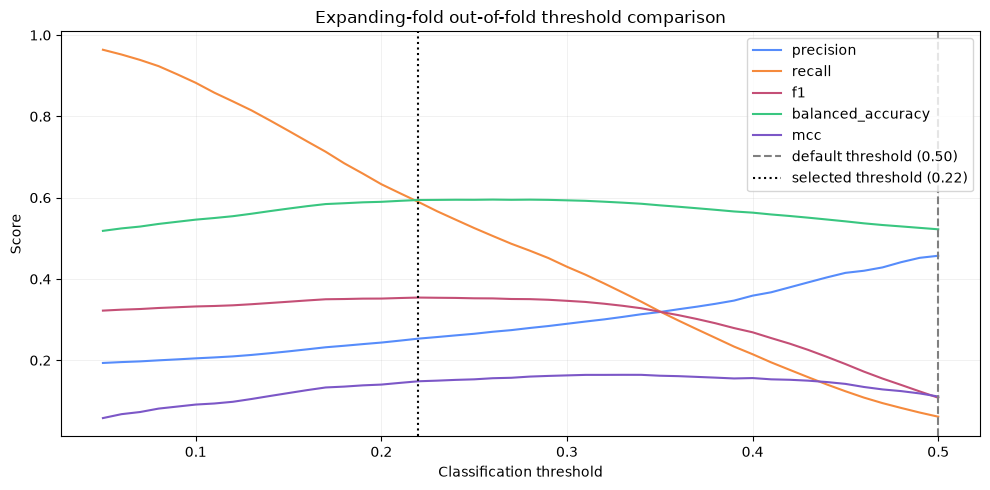

In [12]:
oof_probabilities = np.full(len(y_train), np.nan)
fold_selected_feature_sets = []

for train_indices, validation_indices in temporal_splits:
    fold_model = clone(best_logistic_pipeline)
    fold_model.fit(
        X_train.iloc[train_indices],
        y_train.iloc[train_indices],
    )
    oof_probabilities[validation_indices] = fold_model.predict_proba(
        X_train.iloc[validation_indices]
    )[:, 1]
    fold_selected_feature_sets.append(
        set(get_retained_feature_names(fold_model)[2])
    )

oof_mask = np.isfinite(oof_probabilities)
assert oof_mask.sum() > 0
assert np.isfinite(oof_probabilities[oof_mask]).all()

candidate_thresholds = np.round(np.arange(0.05, 0.501, 0.01), 2)
threshold_rows = []
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]

for threshold in candidate_thresholds:
    predictions = (oof_p >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(oof_y, predictions),
            "balanced_accuracy": balanced_accuracy_score(oof_y, predictions),
            "precision": precision_score(oof_y, predictions, zero_division=0),
            "recall": recall_score(oof_y, predictions, zero_division=0),
            "f1": f1_score(oof_y, predictions, zero_division=0),
            "mcc": matthews_corrcoef(oof_y, predictions),
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).iloc[0]
selected_threshold = float(best_threshold_row["threshold"])

stability_rows = []
for left_index in range(len(fold_selected_feature_sets)):
    for right_index in range(left_index + 1, len(fold_selected_feature_sets)):
        left = fold_selected_feature_sets[left_index]
        right = fold_selected_feature_sets[right_index]
        union = left | right
        stability_rows.append(
            {
                "fold_pair": f"{left_index + 1}-{right_index + 1}",
                "intersection": len(left & right),
                "union": len(union),
                "jaccard_similarity": len(left & right) / len(union),
            }
        )
feature_selection_stability = pd.DataFrame(stability_rows)

selection_frequency = (
    pd.Series(
        [
            feature_name
            for feature_set in fold_selected_feature_sets
            for feature_name in feature_set
        ],
        name="feature",
    )
    .value_counts()
    .rename_axis("feature")
    .rename("folds_selected")
    .to_frame()
)
selection_frequency["selection_rate"] = (
    selection_frequency["folds_selected"] / len(fold_selected_feature_sets)
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
print(
    "Mean pairwise retained-feature Jaccard similarity: "
    f"{feature_selection_stability['jaccard_similarity'].mean():.3f}"
)
display(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).head(10)
)
display(feature_selection_stability)
display(selection_frequency.head(20))

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["precision", "recall", "f1", "balanced_accuracy", "mcc"]:
    ax.plot(threshold_results["threshold"], threshold_results[metric], label=metric)

ax.axvline(0.50, color="gray", linestyle="--", label="default threshold (0.50)")
ax.axvline(
    selected_threshold,
    color="black",
    linestyle=":",
    label=f"selected threshold ({selected_threshold:.2f})",
)
ax.set(
    title="Expanding-fold out-of-fold threshold comparison",
    xlabel="Classification threshold",
    ylabel="Score",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Evaluate the 2023 external validation dataset

The grid-selected estimator was refitted automatically on all 2019 training rows. It is now evaluated on 2023 at both the default 0.50 threshold and the threshold selected from 2019 out-of-fold probabilities. The class-prior dummy provides the no-skill reference.

Threshold changes affect label metrics such as precision and recall, but they do not change average precision, ROC AUC, or Brier score.

In [13]:
def evaluate_probabilities(y_true, probabilities, model_name, threshold):
    """Return threshold, ranking, correlation, and calibration metrics."""
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


validation_probabilities = best_logistic_pipeline.predict_proba(X_validation)[:, 1]

dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train, y_train)
dummy_probabilities = dummy_model.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame(
    [
        evaluate_probabilities(
            y_validation,
            dummy_probabilities,
            "Dummy (2019 class prior)",
            0.50,
        ),
        evaluate_probabilities(
            y_validation,
            validation_probabilities,
            "Logistic regression (default threshold)",
            0.50,
        ),
        evaluate_probabilities(
            y_validation,
            validation_probabilities,
            "Logistic regression (training-selected threshold)",
            selected_threshold,
        ),
    ]
).set_index("model")

evaluation_results


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Dummy (2019 class prior),0.5000,0.7636,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.2364,0.1829
Logistic regression (default threshold),0.5000,0.7644,0.5039,0.6038,0.0097,0.0192,0.0535,0.6762,0.3920,0.1702
Logistic regression (training-selected threshold),0.2200,0.6740,0.6243,0.3683,0.5300,0.4346,0.2230,0.6762,0.3920,0.1702


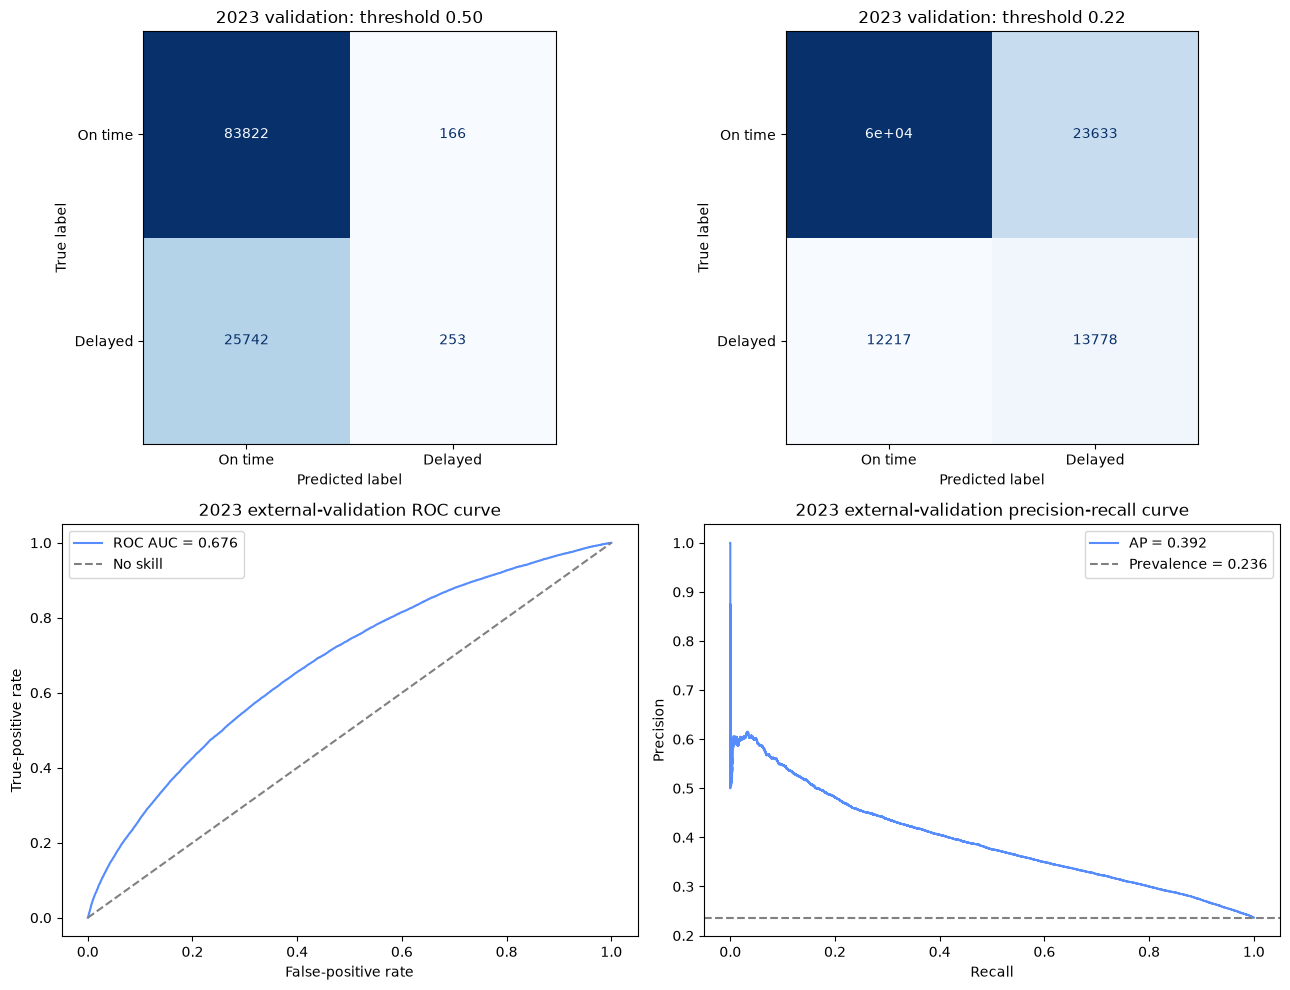

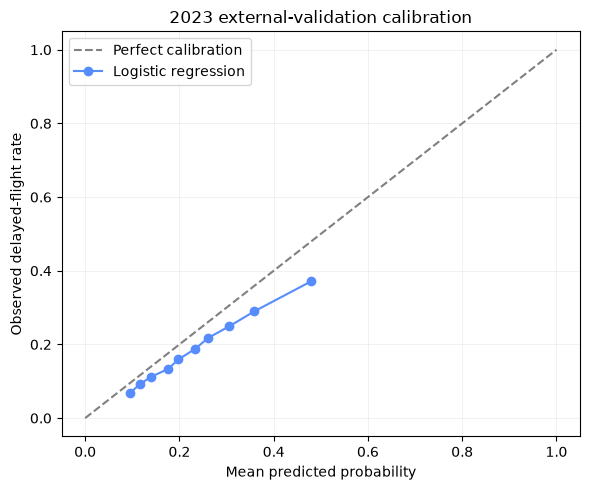

In [14]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)

false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
calibration_predicted, calibration_observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023 validation: threshold 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023 validation: threshold {selected_threshold:.2f}")

axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC AUC = {roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No skill")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="2023 external-validation ROC curve",
)
axes[1, 0].legend()

axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP = {average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(),
    linestyle="--",
    color="gray",
    label=f"Prevalence = {y_validation.mean():.3f}",
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="2023 external-validation precision-recall curve",
)
axes[1, 1].legend()

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(
    calibration_predicted,
    calibration_observed,
    marker="o",
    label="Logistic regression",
)
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delayed-flight rate",
    title="2023 external-validation calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Inspect retained coefficients

Coefficient magnitude is comparable only within this encoded and standardized design matrix. Positive coefficients are associated with greater predicted delay odds and negative coefficients with lower predicted delay odds. They do not establish causal effects. Fold selection frequency above should be considered alongside final-fit magnitude: a large final coefficient that is rarely retained across temporal folds is less stable evidence.


In [15]:
classifier = best_logistic_pipeline.named_steps["classifier"]
coefficient_series = pd.Series(
    classifier.coef_[0],
    index=selected_feature_names,
    name="coefficient",
)

coefficient_table = (
    coefficient_series.rename_axis("feature")
    .reset_index()
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

display(coefficient_table.head(20))

most_positive = coefficient_series.nlargest(10)
most_negative = coefficient_series.nsmallest(10)

coefficient_summary = pd.DataFrame(
    {
        "most_positive_feature": most_positive.index,
        "positive_coefficient": most_positive.values,
        "most_negative_feature": most_negative.index,
        "negative_coefficient": most_negative.values,
    }
)
coefficient_summary


,feature,coefficient,abs_coefficient
1768,numeric__SCHED_DEP_MINUTE_OF_DAY,0.3369,0.3369
1780,numeric__DAY_OF_YEAR_COS,-0.2916,0.2916
87,categorical__ROUTE_JFK_LAX,-0.2142,0.2142
3,categorical__Reporting_Airline_B6,0.1625,0.1625
95,categorical__ROUTE_JFK_ORD,0.1455,0.1455
1799,numeric__HourlyDryBulbTemperature,-0.1416,0.1416
1770,numeric__SCHED_DEP_TIME_SIN,-0.1311,0.1311
1811,numeric__WindX,0.1279,0.1279
1790,numeric__ASPM_THREE_HOUR_TOTAL_SCHEDULED_TRAFFIC,0.1237,0.1237
25,categorical__Dest_FLL,0.1212,0.1212


,most_positive_feature,positive_coefficient,most_negative_feature,negative_coefficient
0,numeric__SCHED_DEP_MINUTE_OF_DAY,0.3369,numeric__DAY_OF_YEAR_COS,-0.2916
1,categorical__Reporting_Airline_B6,0.1625,categorical__ROUTE_JFK_LAX,-0.2142
2,categorical__ROUTE_JFK_ORD,0.1455,numeric__HourlyDryBulbTemperature,-0.1416
3,numeric__WindX,0.1279,numeric__SCHED_DEP_TIME_SIN,-0.1311
4,numeric__ASPM_THREE_HOUR_TOTAL_SCHEDULED_TRAFFIC,0.1237,categorical__Reporting_Airline_AA,-0.1194
5,categorical__Dest_FLL,0.1212,categorical__Reporting_Airline_9E,-0.1052
6,categorical__Dest_BOS,0.1155,numeric__HourlyVisibility,-0.1035
7,numeric__HourlyWindSpeed,0.1017,categorical__TIME_OF_DAY_afternoon,-0.1028
8,numeric__HourlyRelativeHumidity,0.0983,numeric__TEMP_DEWPOINT_SPREAD,-0.0908
9,numeric__PrecipOccurred,0.0767,numeric__Drizzle,-0.0899


## Experiment 03 interpretation checklist

Use the displayed results to answer these questions before promoting the broad top-N representation:

1. Did the broad model improve 2019 temporal-validation and 2023 external-validation average precision over Experiments 01 and 02?
2. Did a 50-, 100-, or 200-feature subset win, or did the search retain all nonconstant encoded columns?
3. Are retained features reasonably stable across the five temporal folds?
4. Did ROC AUC, Brier score, and calibration improve as well as average precision?
5. How much recall was gained—and how much precision was lost—at the 2019-selected threshold?
6. Do high-cardinality flight-identity categories dominate the retained set and coefficients?
7. Is any development-year gain large enough to justify the broader pool and selection complexity?

Treat 2023 as an external development/validation year: its results may motivate a new, separately numbered experiment, but must not be used to refit or tune this Experiment 03 result. Compare all three experiments using their identical 2019 folds, complete 2023 validation population, and metrics. The 2024 dataset remains locked for final evaluation.
